In [1]:
import pandas as pd
import numpy as np
import psycopg2

import secrets
import json

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# print(secrets.token_hex())
conn_path = "../config.json"
conn_params = json.load(open(conn_path))

In [3]:
def execute_query(query: str):
    conn = psycopg2.connect(
        host=conn_params["DB_HOST"],
        database=conn_params["DB_DATABASE"],
        user=conn_params["DB_USER"],
        password=conn_params["DB_PASSWORD"],
        port=conn_params["DB_PORT"],
    )
    cur = conn.cursor()
    cur.execute(query)
    results = cur.fetchall()

    cur.close()
    conn.close()
    return results


def query_data(query: str):
    conn = psycopg2.connect(
        host=conn_params["DB_HOST"],
        database=conn_params["DB_DATABASE"],
        user=conn_params["DB_USER"],
        password=conn_params["DB_PASSWORD"],
        port=conn_params["DB_PORT"],
    )
    cur = conn.cursor()
    # cur.execute(query)
    # results = cur.fetchall()
    df = pd.read_sql_query(query, conn)

    cur.close()
    conn.close()
    return df


def create_scatterplot(df, xcol, ycol, show_corr=True):
    """
    Creates a modern scatterplot from a DataFrame, with both axes starting at 0.

    Parameters:
    df (pd.DataFrame): Input DataFrame.
    xcol (str): Column name for x-axis.
    ycol (str): Column name for y-axis.
    show_corr (bool): Display correlation coefficient. Default: True.
    """
    plt.figure(figsize=(8, 6))
    sns.set_style("whitegrid")
    sns.scatterplot(x=xcol, y=ycol, data=df)
    plt.xlabel(xcol, fontsize=14)
    plt.ylabel(ycol, fontsize=14)
    plt.title(f"Scatterplot of {xcol} vs {ycol}", fontsize=16)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.xlim(0, None)
    plt.ylim(0, None)

    if show_corr:
        corr_coef = df[xcol].corr(df[ycol])
        plt.text(
            0.1,
            0.9,
            f"Correlation: {corr_coef:.2f}",
            transform=plt.gca().transAxes,
            fontsize=12,
        )

        # Add dotted red trendline
        z = np.polyfit(df[xcol], df[ycol], 1)
        p = np.poly1d(z)
        plt.plot(df[xcol], p(df[xcol]), "r--")

    plt.show()

In [4]:
db_query = f"""
select *
from information_schema.tables 
"""

query_data(db_query)[query_data(db_query)["table_schema"] == "public"]["table_name"]

/var/folders/x7/xhgs2dv1471469zrfltg22l00000gn/T/ipykernel_62827/330992027.py:29: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, conn)


0                           nflfastR_player_stats
1                                    nflfastR_pbp
2                    nflfastR_player_stats_weekly
5                             nflfastR_team_stats
6                      nflfastR_team_stats_weekly
7                team_stats.all.all_seasons.total
8                                            part
9      player_stats.passing.current_season_weekly
10            team_stats.all.current_season.total
11                                 ngs_highlights
15                            ffpros_ecr_rankings
23                                   cfbfastR_pbp
24                               nflfastR_players
25                               nflfastR_rosters
26                             nflfastR_contracts
27                             nflfastR_officials
28                   nflfastR_player_stats_season
29                              nflfastR_schedule
30                                nflfastR_trades
31                                 nflfastR_draft


In [22]:
game_id_query = f"""
select distinct
    -- logos_home.team_name as home_team_name,
    -- logos_away.team_name as away_team_name,
    -- pbp.home_team,
    -- pbp.away_team,
    concat_ws(
        '-',
        lower(logos_away.team_nick),
        'at',
        lower(logos_home.team_nick),
        pbp.season,
        lower(pbp.season_type),
        pbp.week-18
    ) as slug,
    pbp.game_id,
    -- pbp.nfl_api_id,
    NULL
from
    \"nflfastR_pbp\" pbp
left join \"nflfastR_logos\" logos_home on logos_home.team_abbr = pbp.home_team
left join \"nflfastR_logos\" logos_away on logos_away.team_abbr = pbp.away_team
where
    pbp.posteam = 'PHI'
    and pbp.season IN ('2017', '2022', '2024')
    and pbp.season_type = 'POST'
order by
    game_id
"""

query_data(game_id_query)

/var/folders/x7/xhgs2dv1471469zrfltg22l00000gn/T/ipykernel_62827/330992027.py:29: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, conn)


,slug,game_id,?column?
0,falcons-at-eagles-2017-post-1,2017_19_ATL_PHI,None
1,vikings-at-eagles-2017-post-2,2017_20_MIN_PHI,None
2,eagles-at-patriots-2017-post-3,2017_21_PHI_NE,None
3,giants-at-eagles-2022-post-2,2022_20_NYG_PHI,None
4,49ers-at-eagles-2022-post-3,2022_21_SF_PHI,None
5,chiefs-at-eagles-2022-post-4,2022_22_KC_PHI,None
6,packers-at-eagles-2024-post-1,2024_19_GB_PHI,None
7,rams-at-eagles-2024-post-2,2024_20_LA_PHI,None
8,commanders-at-eagles-2024-post-3,2024_21_WAS_PHI,None
9,chiefs-at-eagles-2024-post-4,2024_22_KC_PHI,None


In [5]:
season = 2015
boolean = ">="

pbp_query = f"""
select
    season,
    posteam,
    game_id,
    receiver_player_id,
    receiver_player_name,
    air_yards,
    pass_attempt
from 
    \"nflfastR_pbp\" 
where 
    season {boolean} {season}
"""

In [6]:
df = query_data(pbp_query)

/var/folders/x7/xhgs2dv1471469zrfltg22l00000gn/T/ipykernel_8833/330992027.py:29: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, conn)


In [7]:
season = 2015
boolean = ">="

roster_query = f"""
select *
from \"nflfastR_rosters\"
where season {boolean} {season}
"""

roster_df = query_data(roster_query)

roster_df = roster_df[["season", "gsis_id", "position"]]
roster_df.head()

/var/folders/x7/xhgs2dv1471469zrfltg22l00000gn/T/ipykernel_8833/330992027.py:29: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, conn)


,season,gsis_id,position
0,2015,00-0004091,K
1,2015,00-0007091,QB
2,2015,00-0010346,QB
3,2015,00-0016919,K
4,2015,00-0018227,FS


In [8]:
passes_df = df

dimension_cols = [
    "season_n",
    "posteam",
    "game_id",
    "receiver_player_id",
    "receiver_player_name",
    # "passer_player_id",
    # "passer_player_name",
]


measurement_cols = [
    "air_yards",
    "pass_attempt",
]

passes_df = passes_df.rename(columns={"season": "season_n"})
passes_df = passes_df[passes_df["pass_attempt"] == 1][dimension_cols + measurement_cols]

targets_df = (
    passes_df
    .groupby(dimension_cols)
    [measurement_cols]
    .agg(["sum"])
    .reset_index()
)
targets_df["gp"] = 1
targets_df["air_yards_per_attempt"] = (
    targets_df["air_yards"] / targets_df["pass_attempt"]
)
targets_df["season_n1"] = targets_df["season_n"] + 1

targets_df.columns = targets_df.columns.droplevel(1)

dimension_cols = [
    "season_n",
    "season_n1",
    "receiver_player_id",
    "receiver_player_name",
]

measurement_cols = [
    "air_yards",
    "pass_attempt",
    "gp",
]

targets_df = (
    targets_df
    .groupby(dimension_cols)
    [measurement_cols]
    .agg(["sum"])
    .reset_index()
)

targets_df.columns = targets_df.columns.droplevel(1)

targets_df["air_yards_game"] = targets_df["air_yards"] / targets_df["gp"]

In [9]:
targets_df

,season_n,season_n1,receiver_player_id,receiver_player_name,air_yards,pass_attempt,gp,air_yards_game
0,2015,2016,00-0019596,T.Brady,7.0,1.0,1,7.000000
1,2015,2016,00-0020337,S.Smith,719.0,73.0,7,102.714286
2,2015,2016,00-0021547,A.Gates,696.0,85.0,11,63.272727
3,2015,2016,00-0022044,A.Johnson,792.0,78.0,16,49.500000
4,2015,2016,00-0022084,A.Boldin,894.0,112.0,14,63.857143
...,...,...,...,...,...,...,...,...
4619,2023,2024,00-0039139,J.Gibbs,12.0,86.0,18,0.666667
4620,2023,2024,00-0039144,L.Musgrave,403.0,53.0,13,31.000000
4621,2023,2024,00-0039146,J.Reed,1011.0,102.0,18,56.166667
4622,2023,2024,00-0039163,C.Stroud,-1.0,1.0,1,-1.000000


In [10]:
measurement_cols = [
    "air_yards_game",
]

merged_df = (
    targets_df[
        ["season_n", "receiver_player_id", "receiver_player_name"] + measurement_cols
    ]
    .merge(
        targets_df[
            ["season_n1", "receiver_player_id", "receiver_player_name"]
            + measurement_cols
        ],
        left_on=["receiver_player_id", "receiver_player_name", "season_n"],
        right_on=["receiver_player_id", "receiver_player_name", "season_n1"],
        suffixes=("_n", "_n1"),
        how="left",
    )
    .merge(
        roster_df,
        left_on=["season_n", "receiver_player_id"],
        right_on=["season", "gsis_id"],
        how="left",
    )
)

merged_df = merged_df[merged_df["position"] == "WR"]

merged_df.head()

,season_n,receiver_player_id,receiver_player_name,air_yards_game_n,season_n1,air_yards_game_n1,season,gsis_id,position
1,2015,00-0020337,S.Smith,102.714286,NaN,NaN,2015,00-0020337,WR
3,2015,00-0022044,A.Johnson,49.500000,NaN,NaN,2015,00-0022044,WR
4,2015,00-0022084,A.Boldin,63.857143,NaN,NaN,2015,00-0022084,WR
6,2015,00-0022414,M.Floyd,92.466667,NaN,NaN,2015,00-0022414,WR
7,2015,00-0022427,W.Welker,17.000000,NaN,NaN,2015,00-0022427,WR


In [11]:
merged_df.sort_values("air_yards_game_n", ascending=False)

,season_n,receiver_player_id,receiver_player_name,air_yards_game_n,season_n1,air_yards_game_n1,season,gsis_id,position
2149,2019,00-0031235,O.Beckham Jr.,169.000000,NaN,NaN,2019,00-0031235,WR
343,2015,00-0030564,D.Hopkins,166.764706,NaN,NaN,2015,00-0030564,WR
836,2016,00-0031408,M.Evans,160.187500,2016.0,147.200000,2016,00-0031408,WR
1077,2017,00-0027793,A.Brown,156.333333,2017.0,104.000000,2017,00-0027793,WR
214,2015,00-0029137,A.Jeffery,152.333333,NaN,NaN,2015,00-0029137,WR
...,...,...,...,...,...,...,...,...,...
3742,2022,00-0033111,P.Cooper,-6.000000,2022.0,13.166667,2022,00-0033111,WR
4347,2023,00-0035527,A.Isabella,-6.000000,2023.0,35.000000,2023,00-0035527,WR
2629,2020,00-0030525,T.Austin,-7.333333,2020.0,24.916667,2020,00-0030525,WR
3450,2021,00-0035500,G.Dortch,-8.000000,NaN,NaN,2021,00-0035500,WR


In [27]:
def create_scatterplot(
    df: pd.DataFrame, 
    xcol: str, 
    ycol: str, 
    show_corr: bool = True, 
    trendline_style: str = "r--"
) -> None:
    """
    Creates a modern scatterplot from a DataFrame, with both axes starting at 0.

    Args:
    df (pd.DataFrame): Input DataFrame.
    xcol (str): Column name for x-axis.
    ycol (str): Column name for y-axis.
    show_corr (bool, optional): Display correlation coefficient. Defaults to True.
    trendline_style (str, optional): Trendline color and style. Defaults to "r--" (red dashed).

    Raises:
    ValueError: If xcol or ycol are not valid column names in the DataFrame.
    """
    # Check if xcol and ycol are valid column names
    if xcol not in df.columns or ycol not in df.columns:
        raise ValueError("Invalid column name. Please check the column names in the DataFrame.")

    plt.figure(figsize=(8, 6))
    sns.set_style("whitegrid")
    sns.scatterplot(x=xcol, y=ycol, data=df)
    plt.xlabel(xcol, fontsize=14)
    plt.ylabel(ycol, fontsize=14)
    plt.title(f'Scatterplot of {xcol} vs {ycol}', fontsize=16)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.xlim(0, None)
    plt.ylim(0, None)
    
    if show_corr:
        corr_coef = df[xcol].corr(df[ycol])
        plt.text(0.1, 0.9, f'Correlation: {corr_coef:.2f}', transform=plt.gca().transAxes, fontsize=12)
        
        # Add trendline
        z = np.polyfit(df[xcol], df[ycol], 1)
        p = np.poly1d(z)
        plt.plot(df[xcol], p(df[xcol]), trendline_style)
    
    plt.show()

/var/folders/x7/xhgs2dv1471469zrfltg22l00000gn/T/ipykernel_8833/3228477682.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  plot_df = merged_df.dropna(subset=["air_yards_game_n", "air_yards_game_n1"])[


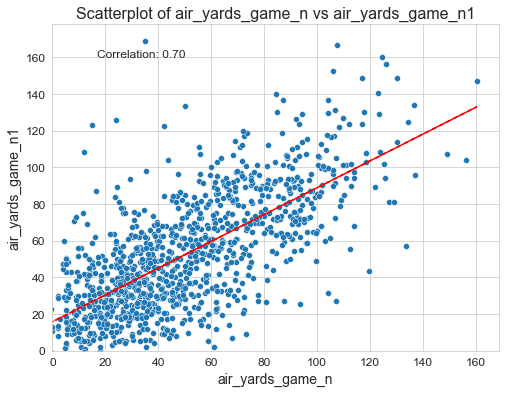

In [28]:
plot_df = merged_df.dropna(subset=["air_yards_game_n", "air_yards_game_n1"])[
    (merged_df["season_n"] > 2015) & (merged_df["season_n"] < 2023)
]
plot_df.head(20)

# Create a scatterplot
create_scatterplot(plot_df, "air_yards_game_n", "air_yards_game_n1", show_corr=True)